In [37]:
%reload_ext autoreload
%autoreload 2
%matplotlib inline

import re
import joblib
import random
import numpy as np
import scipy as sp
from matplotlib import pyplot as plt
import matplotlib as mpl
from syd import make_viewer, Viewer
from tqdm import tqdm
import optuna

from vrAnalysis.database import get_database
from vrAnalysis.helpers import Timer, get_placefield_location, uniq_val_filter
from vrAnalysis.processors.em import process_session
from vrAnalysis.processors.placefields import get_placefield, get_placefield_prediction, convert_position_to_bins
from vrAnalysis.processors.support import get_gauss_kernel, convolve_toeplitz, smooth
from dimensionality_manuscript.registry import PopulationRegistry
from dimensionality_manuscript import LocPredConfig
from dimensionality_manuscript import ResultsStore, ResultsAggregator

plt.rcParams["font.size"] = 18

# get session database
sessiondb = get_database("vrSessions")

# get population registry and models
registry = PopulationRegistry()
cfg = LocPredConfig(norm_method="zero-one", norm_scale=1.0, fit_iterations=5)

In [38]:
isession = 41
spks_type = "oasis"
session_iterable = sessiondb.iter_sessions(imaging=True, session_params=dict(spks_type=spks_type))

# session = random.choice([s for s in session_iterable if s.mouse_name == "ATL027"])
session = session_iterable[isession]
print(session)
print(session.environments)

fit = cfg.fit(session, registry)
hyperparameters = cfg.optimize(session, registry, fit)
score_null = cfg.score(session, registry, fit, hyperparameters=None, iteration=0)
score = cfg.score(session, registry, fit, hyperparameters=hyperparameters, iteration=0)

# Full process with iterations and stuff
results = cfg.process(session, registry)

B2Session(mouse_name='ATL022', date='2023-04-18', session_id='701', spks_type='oasis')
[1 3]


In [39]:
loss_types = [re.fullmatch(r"poisson_(.+)", k).group(1) for k in score["loss_scalar"].keys() if re.fullmatch(r"poisson_(.+)", k)]
print("Loss types:")
for loss_type in loss_types:
    print(f"  {loss_type}")

print("Likelihood methods:")
print(cfg.likelihood_methods)

print("Results:")
print("\n   ".join(list(results.keys())))

Loss types:
  cross_entropy
  rank_loss_logistic_mean
  rank_loss_hinge_mean
  rank_metric_mean_rank
  rank_metric_top1
  rank_metric_top5
  rank_metric_top10
  distance_error
  env_swap
Likelihood methods:
('poisson', 'gaussian', 'diag_gaussian', 'von_mises_fisher')
Results:
likelihood_matrix
   loss_trajectory
   loss_scalar
   true_bin_score
   true_position_bins_te
   idx_keep_rois
   iteration_position_bins_tr


In [40]:
# For looking how the test scores change across iterations of fit (in EM routine)
method_width = max(len(method) for method in cfg.likelihood_methods)

for loss_type in loss_types:
    print(f"Loss type: {loss_type}")
    for method in cfg.likelihood_methods:
        _scores = np.array(results["loss_scalar"][f"{method}_{loss_type}"])
        _scores = _scores / np.min(_scores)
        _scores = np.array([np.round(s, 3) for s in _scores])
        print(f"  {method.ljust(method_width)}: {_scores}")

Loss type: cross_entropy
  poisson         : [1.    1.134 1.239 1.396 1.578]
  gaussian        : [1.    1.155 1.286 1.413 1.574]
  diag_gaussian   : [1.    1.23  1.632 2.245 3.378]
  von_mises_fisher: [1.    1.224 1.375 1.488 1.589]
Loss type: rank_loss_logistic_mean
  poisson         : [1.    2.251 3.07  4.958 7.21 ]
  gaussian        : [1.    1.705 2.387 3.195 4.33 ]
  diag_gaussian   : [ 1.     2.227  4.184 10.786 31.182]
  von_mises_fisher: [1.    2.001 2.833 3.478 3.965]
Loss type: rank_loss_hinge_mean
  poisson         : [1.    2.13  3.093 5.147 8.22 ]
  gaussian        : [1.    1.723 2.476 3.38  4.748]
  diag_gaussian   : [ 1.     2.637  5.034 12.392 33.808]
  von_mises_fisher: [1.    1.957 2.906 3.632 4.205]
Loss type: rank_metric_mean_rank
  poisson         : [1.    1.793 2.806 4.556 6.488]
  gaussian        : [1.    1.695 2.427 3.277 4.509]
  diag_gaussian   : [1.    1.871 2.924 4.553 6.793]
  von_mises_fisher: [1.    1.732 2.431 2.986 3.448]
Loss type: rank_metric_top1
  poi

In [41]:
# For comparing without validation to with validation
method_width = max(len(method) for method in cfg.likelihood_methods)

for loss_type in loss_types:
    print(loss_type)

    for likelihood_method in cfg.likelihood_methods:
        _score_null = score_null["loss_scalar"][f"{likelihood_method}_{loss_type}"]
        _score = score["loss_scalar"][f"{likelihood_method}_{loss_type}"]

        print(f"   {likelihood_method:<{method_width}} : " f"{_score_null:8.2f} -> {_score:8.2f}")

cross_entropy
   poisson          :    13.99 ->     3.77
   gaussian         :     2.93 ->     3.66
   diag_gaussian    :   100.03 ->     2.48
   von_mises_fisher :     5.07 ->     3.31
rank_loss_logistic_mean
   poisson          :     0.39 ->     0.25
   gaussian         :     0.11 ->     0.26
   diag_gaussian    :     2.62 ->     0.06
   von_mises_fisher :     0.58 ->     0.15
rank_loss_hinge_mean
   poisson          :     0.41 ->     0.15
   gaussian         :     0.09 ->     0.20
   diag_gaussian    :     2.64 ->     0.06
   von_mises_fisher :     0.76 ->     0.11
rank_metric_mean_rank
   poisson          :     5.49 ->     5.49
   gaussian         :     8.08 ->     8.08
   diag_gaussian    :     5.74 ->     5.74
   von_mises_fisher :     6.33 ->     6.33
rank_metric_top1
   poisson          :     0.19 ->     0.19
   gaussian         :     0.17 ->     0.17
   diag_gaussian    :     0.20 ->     0.20
   von_mises_fisher :     0.18 ->     0.18
rank_metric_top5
   poisson          :    

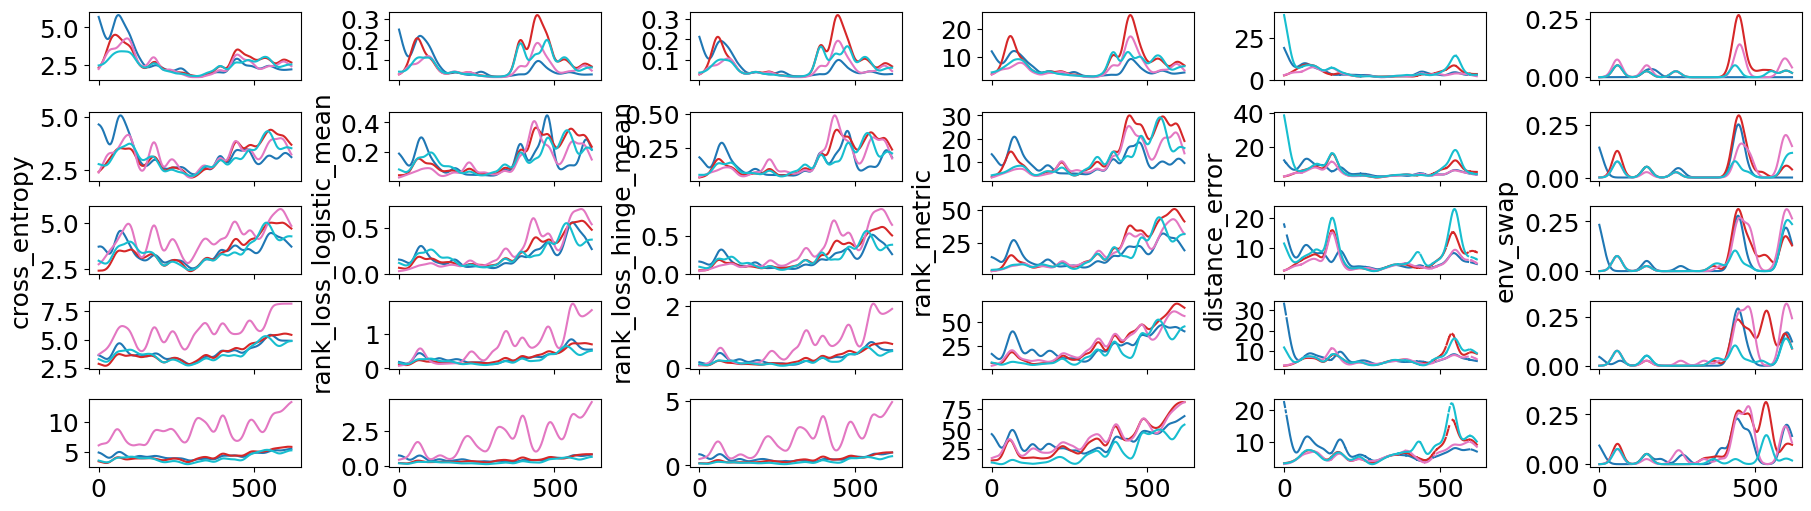

In [ ]:
from scipy.stats import zscore

# Get m
num_loss = len(cfg.loss_methods)
num_ll = len(cfg.likelihood_methods)
colors = plt.colormaps["tab10"](np.linspace(0, 1, num_ll))

num_iterations = cfg.fit_iterations
norm = lambda x: x  # zscore(x, axis=-1, nan_policy="omit")

plt.close("all")
fig, ax = plt.subplots(num_iterations, num_loss, figsize=(3 * num_loss, 5), layout="constrained", sharex=True)
for iloss, loss_method in enumerate(cfg.loss_methods):
    for ill, ll_method in enumerate(cfg.likelihood_methods):
        ckey = f"{ll_method}_{loss_method}"
        cval = results["loss_trajectory"][ckey]
        xx = np.arange(cval.shape[-1])
        fval = smooth(cval, xx, 11)
        for iteration in range(num_iterations):
            ax[iteration, iloss].plot(norm(fval[iteration]), color=colors[ill], label=ll_method)
    ax[2, iloss].set_ylabel(loss_method)
    # ax[iloss].legend()

plt.show()

In [43]:
for k, val in results["true_bin_score"].items():
    print(f"{k}: {val.shape}")

poisson: (5, 621)
gaussian: (5, 621)
diag_gaussian: (5, 621)
von_mises_fisher: (5, 621)


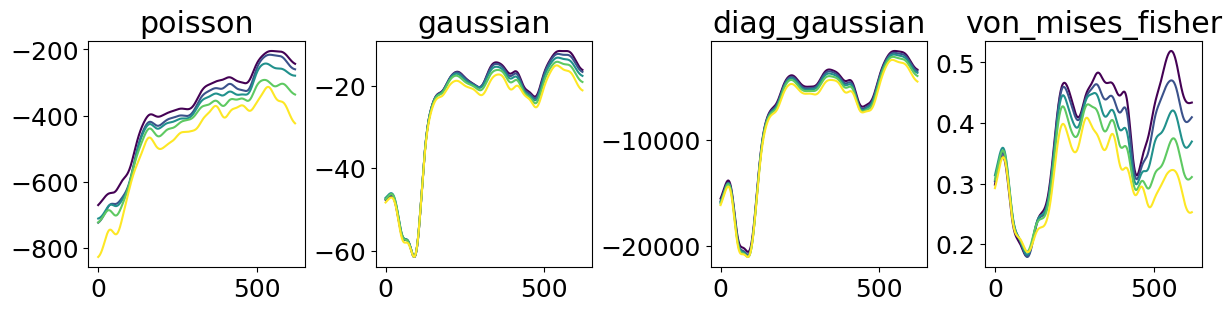

In [44]:
# Get m
num_ll = len(cfg.likelihood_methods)
num_iterations = cfg.fit_iterations
colors = plt.colormaps["viridis"](np.linspace(0, 1, num_iterations))

norm = lambda x: x  # zscore(x, axis=-1, nan_policy="omit")

plt.close("all")
fig, ax = plt.subplots(1, num_ll, figsize=(3 * num_ll, 3), layout="constrained", sharex=True)
for ill, ll_method in enumerate(cfg.likelihood_methods):
    cval = results["true_bin_score"][ll_method]
    xx = np.arange(cval.shape[-1])
    fval = smooth(cval, xx, 11)
    for iteration in range(num_iterations):
        ax[ill].plot(norm(fval[iteration]), color=colors[iteration], label=ll_method)
    ax[ill].set_title(ll_method)

plt.show()